In [2]:
import random
import pandas as pd
import numpy as np
import pwlf

RANDOM_STATE = 123
random.seed(RANDOM_STATE)

N = 20
df_name = "AAPL_15min"

df = pd.read_csv(f'datasets/{df_name}_marked.csv')

TRAIN_SIZE = int(0.8 * df.shape[0])
df_train, df_test = df[:TRAIN_SIZE], df[TRAIN_SIZE:]

In [3]:
def build_vectors_by_slopes(df, N, take_all=False):
    vectors = []
    n = df.shape[0]
    for i in range(N, n):
        if df.iloc[i]['is_min'] or take_all:
            x = np.arange(N + 1)
            y = df.iloc[i-N:i + 1]['close'].values
            model = pwlf.PiecewiseLinFit(x, y)
            _ = model.fit(4)
            vectors.append(model.slopes)
    return np.array(vectors)

X_train = build_vectors_by_slopes(df_train, N)
X_train.shape

(276, 4)

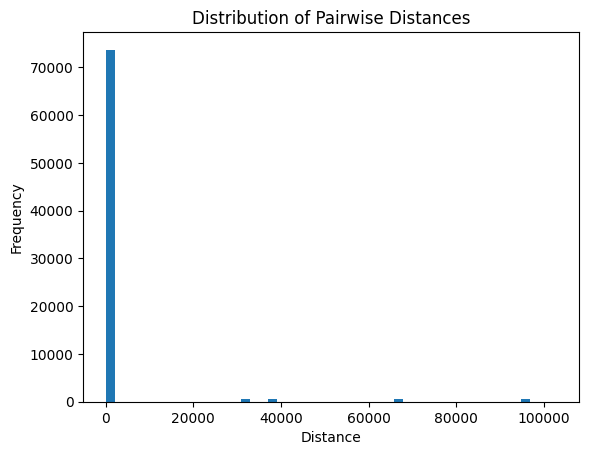

In [5]:
from matplotlib import pyplot as plt
from sklearn.metrics.pairwise import euclidean_distances

distances = euclidean_distances(X_train)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=50)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

Как можно заметить, расстояния нерепрезентативны. Это происходит из-за того, что наклоны прямых могут иметь очень разные масштаб, а также могут быть выбросы.

Допустим, для двух экстремумов:
$V1 = [8500, -4300, 1.0]$

$V2 = [8600, -4400, 1.5]$

Евклидово расстояние:
$d = sqrt((8600-8500)^2 + (-4400-(-4300))^2 + (1.5-1.0)^2)
  = sqrt(10000 + 10000 + 0.25)
  ≈ 141$
  
Третий признак (slope=1.0) вообще не влияет на расстояние, потому что первые два признака на порядки больше. Фактически кластеризация идёт только по двум числам, а третье игнорируется.

Плюс, pwlf иногда строит прямые с очень большими по модулю наклонами и очень близкими концами, хотя можно отдалить концы, и тогда наклоны станут адекватнее (это в нашем случае и есть выбросы)

In [52]:
lower = np.percentile(X_train, 3, axis=0)
upper = np.percentile(X_train, 97, axis=0)
print("Lower percentiles (3%):", lower)
print("Upper percentiles (97%):", upper)

mask = np.all((X_train >= lower) & (X_train <= upper), axis=1)
X_train_clean = X_train[mask]

print(f"Осталось {mask.sum()} из {len(mask)} точек")

Lower percentiles (3%): [-1.54639162 -7.94167562 -9.88505966 -1.67557117]
Upper percentiles (97%): [1.14508482 6.59061655 4.15611024 7.87615876]
Осталось 212 из 276 точек


In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)

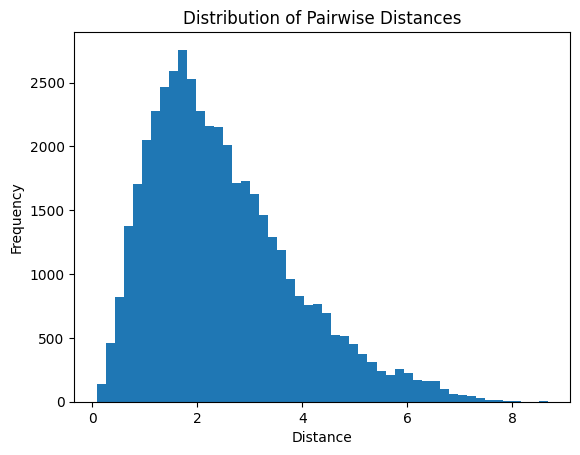

In [54]:
distances = euclidean_distances(X_train_scaled)

plt.hist([dist for row in distances for dist in row if dist > 0], bins=50)
plt.xlabel('Distance')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Distances')
plt.show()

In [55]:
print("Max values:")
print(np.max(X_train_scaled, axis=0))
print("Min values:")
print(np.min(X_train_scaled, axis=0))
print("Median values:")
print(np.median(X_train_scaled, axis=0))

Max values:
[2.77203355 3.29988539 2.6394863  5.5973927 ]
Min values:
[-3.79229709 -3.99053029 -4.69274476 -1.63279153]
Median values:
[ 0.02475644  0.08106637  0.20304751 -0.2859775 ]


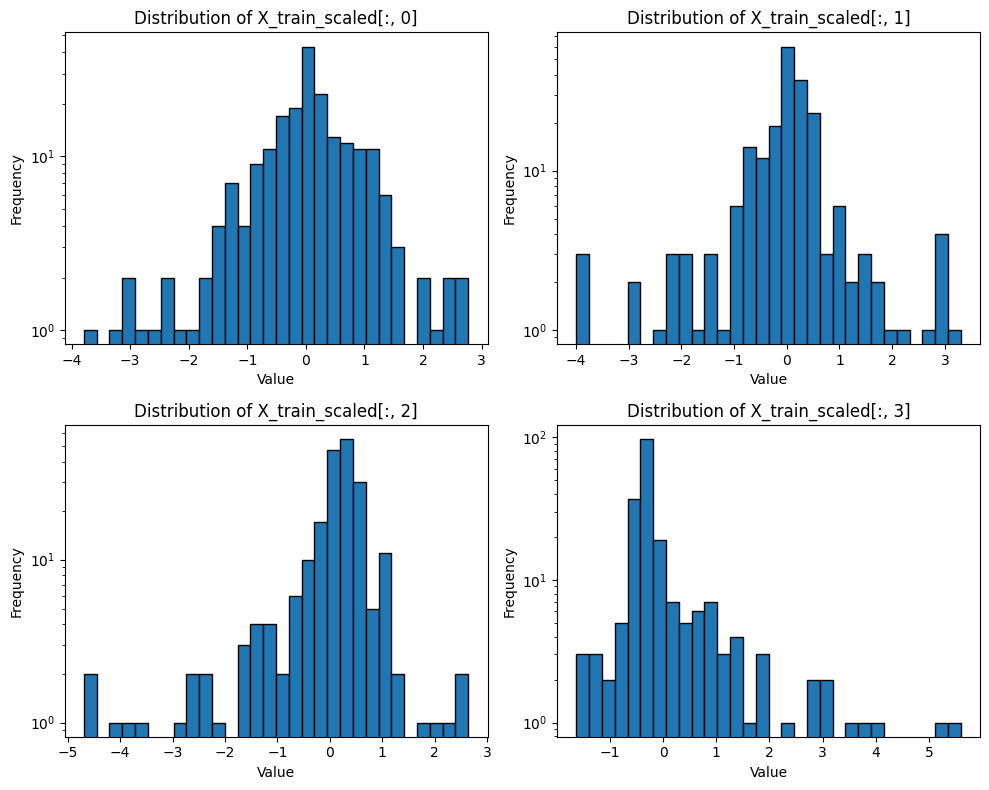

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for i in range(4):
    row = i // 2
    col = i % 2
    axes[row, col].hist(X_train_scaled[:, i], bins=30, edgecolor='black')
    axes[row, col].set_xlabel('Value')
    axes[row, col].set_ylabel('Frequency')
    axes[row, col].set_title(f'Distribution of X_train_scaled[:, {i}]')
    axes[row, col].set_yscale('log')

plt.tight_layout()
plt.show()

In [60]:
from sklearn.cluster import DBSCAN, KMeans

for eps in [1.0, 1.5, 2.0, 2.5, 3.0]:
    clustering = DBSCAN(eps=eps, min_samples=5).fit(X_train_scaled)
    n_clusters = len(set(clustering.labels_)) - (1 if -1 in clustering.labels_ else 0)
    n_noise = np.sum(clustering.labels_ == -1)
    print(f"eps={eps}: кластеров={n_clusters}, шум={n_noise}")

eps=1.0: кластеров=1, шум=31
eps=1.5: кластеров=1, шум=13
eps=2.0: кластеров=1, шум=3
eps=2.5: кластеров=1, шум=1
eps=3.0: кластеров=1, шум=1


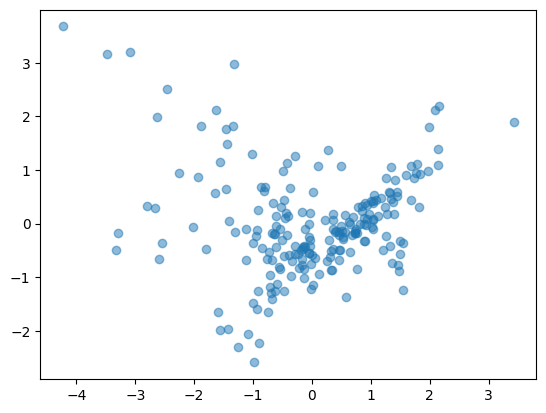

In [63]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_train_scaled)

plt.scatter(X_2d[:, 0], X_2d[:, 1], alpha=0.5)
plt.show()